In [ ]:
# Importing the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Read the Dataset using your exact file path
data = pd.read_csv(r"C:\Users\karthik\Downloads\Pumpkin_Seeds_Dataset.xlsx - Pumpkin_Seeds_Dataset.csv")

# Display the first 5 rows to verify it loaded correctly
print(data.head())

    Area  Perimeter  Major_Axis_Length  Minor_Axis_Length  Convex_Area  \
0  56276    888.242           326.1485           220.2388        56831   
1  76631   1068.146           417.1932           234.2289        77280   
2  71623   1082.987           435.8328           211.0457        72663   
3  66458    992.051           381.5638           222.5322        67118   
4  66107    998.146           383.8883           220.4545        67117   

   Equiv_Diameter  Eccentricity  Solidity  Extent  Roundness  Aspect_Ration  \
0        267.6805        0.7376    0.9902  0.7453     0.8963         1.4809   
1        312.3614        0.8275    0.9916  0.7151     0.8440         1.7811   
2        301.9822        0.8749    0.9857  0.7400     0.7674         2.0651   
3        290.8899        0.8123    0.9902  0.7396     0.8486         1.7146   
4        290.1207        0.8187    0.9850  0.6752     0.8338         1.7413   

   Compactness       Class  
0       0.8207  Çerçevelik  
1       0.7487  Çerçev

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Area               2500 non-null   int64  
 1   Perimeter          2500 non-null   float64
 2   Major_Axis_Length  2500 non-null   float64
 3   Minor_Axis_Length  2500 non-null   float64
 4   Convex_Area        2500 non-null   int64  
 5   Equiv_Diameter     2500 non-null   float64
 6   Eccentricity       2500 non-null   float64
 7   Solidity           2500 non-null   float64
 8   Extent             2500 non-null   float64
 9   Roundness          2500 non-null   float64
 10  Aspect_Ration      2500 non-null   float64
 11  Compactness        2500 non-null   float64
 12  Class              2500 non-null   object 
dtypes: float64(10), int64(2), object(1)
memory usage: 254.0+ KB


In [6]:
# Removing the outliers for the "Area" column
# Calculate the first and third quartiles
Q1 = data["Area"].quantile(0.25)
Q3 = data["Area"].quantile(0.75)

# Calculate the interquartile range (IQR)
IQR = Q3 - Q1

# Define the lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Rows before outlier removal:", data.shape[0])

# Filter out outliers and keep only the valid data
data = data[(data["Area"] >= lower_bound) & (data["Area"] <= upper_bound)]

print("Rows after outlier removal:", data.shape[0])

Rows before outlier removal: 2500
Rows after outlier removal: 2482


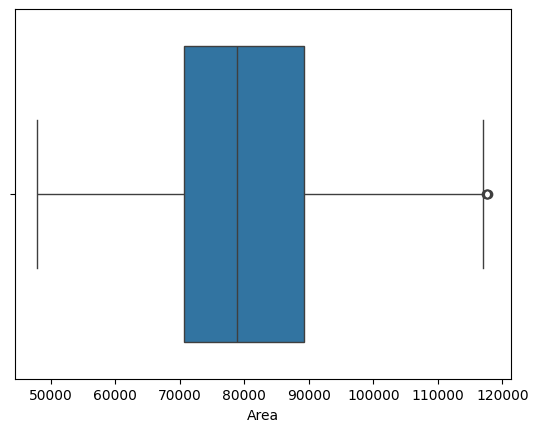

In [7]:
# Visualize the cleaned 'Area' column
sns.boxplot(x=data['Area'])
plt.show()

In [8]:
from sklearn.preprocessing import MinMaxScaler

columns_to_scale = ['Area', 'Perimeter', 'Major_Axis_Length']

# Apply MinMaxScaler only to selected columns
scaler = MinMaxScaler()
data[columns_to_scale] = scaler.fit_transform(data[columns_to_scale])

# Display the resulting DataFrame (showing the first 5 rows)
print(data.head())

       Area  Perimeter  Major_Axis_Length  Minor_Axis_Length  Convex_Area  \
0  0.119284   0.033709           0.016192           220.2388        56831   
1  0.410519   0.340661           0.294143           234.2289        77280   
2  0.338866   0.365983           0.351048           211.0457        72663   
3  0.264966   0.210828           0.185370           222.5322        67118   
4  0.259944   0.221228           0.192467           220.4545        67117   

   Equiv_Diameter  Eccentricity  Solidity  Extent  Roundness  Aspect_Ration  \
0        267.6805        0.7376    0.9902  0.7453     0.8963         1.4809   
1        312.3614        0.8275    0.9916  0.7151     0.8440         1.7811   
2        301.9822        0.8749    0.9857  0.7400     0.7674         2.0651   
3        290.8899        0.8123    0.9902  0.7396     0.8486         1.7146   
4        290.1207        0.8187    0.9850  0.6752     0.8338         1.7413   

   Compactness       Class  
0       0.8207  Çerçevelik  
1   

In [9]:
# Dropping up some columns
data = data.drop(columns=['Convex_Area', 'Equiv_Diameter', 'Eccentricity', 'Minor_Axis_Length'], axis=1)

# Display the first 5 rows to confirm the columns are gone
print(data.head())

       Area  Perimeter  Major_Axis_Length  Solidity  Extent  Roundness  \
0  0.119284   0.033709           0.016192    0.9902  0.7453     0.8963   
1  0.410519   0.340661           0.294143    0.9916  0.7151     0.8440   
2  0.338866   0.365983           0.351048    0.9857  0.7400     0.7674   
3  0.264966   0.210828           0.185370    0.9902  0.7396     0.8486   
4  0.259944   0.221228           0.192467    0.9850  0.6752     0.8338   

   Aspect_Ration  Compactness       Class  
0         1.4809       0.8207  Çerçevelik  
1         1.7811       0.7487  Çerçevelik  
2         2.0651       0.6929  Çerçevelik  
3         1.7146       0.7624  Çerçevelik  
4         1.7413       0.7557  Çerçevelik  


In [10]:
data.describe()

,Area,Perimeter,Major_Axis_Length,Solidity,Extent,Roundness,Aspect_Ration,Compactness
count,2482.000000,2482.000000,2482.000000,2482.000000,2482.000000,2482.000000,2482.000000,2482.000000
mean,0.463459,0.442677,0.411127,0.989479,0.693502,0.791838,2.039858,0.704435
std,0.188186,0.180938,0.167586,0.003499,0.060676,0.055916,0.315819,0.053053
min,0.000000,0.000000,0.000000,0.918600,0.468000,0.554600,1.148700,0.560800
25%,0.325145,0.307016,0.285968,0.988300,0.659300,0.752325,1.800325,0.663900
50%,0.443448,0.433898,0.391094,0.990300,0.713250,0.798200,1.982850,0.707900
75%,0.592092,0.567014,0.522056,0.991500,0.740275,0.834575,2.258775,0.743700
max,1.000000,1.000000,1.000000,0.994400,0.829600,0.939600,3.144400,0.904900


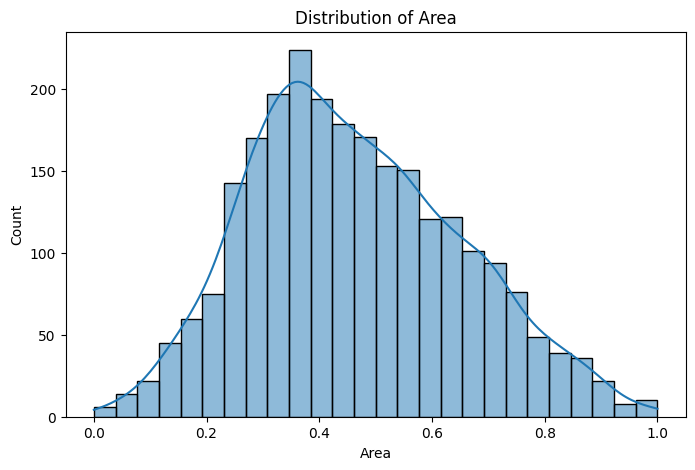

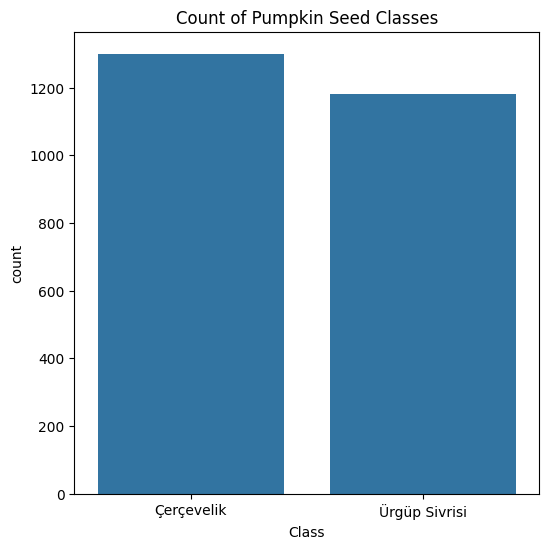

In [11]:
# 1. Distribution Plot for Area
# (Using 'Area' instead of 'Convex_Area' since we dropped it earlier)
plt.figure(figsize=(8, 5))
sns.histplot(data['Area'], kde=True)
plt.title('Distribution of Area')
plt.show()

# 2. Count Plot for Class values
plt.figure(figsize=(6, 6))
sns.countplot(data=data, x='Class')
plt.title('Count of Pumpkin Seed Classes')
plt.show()

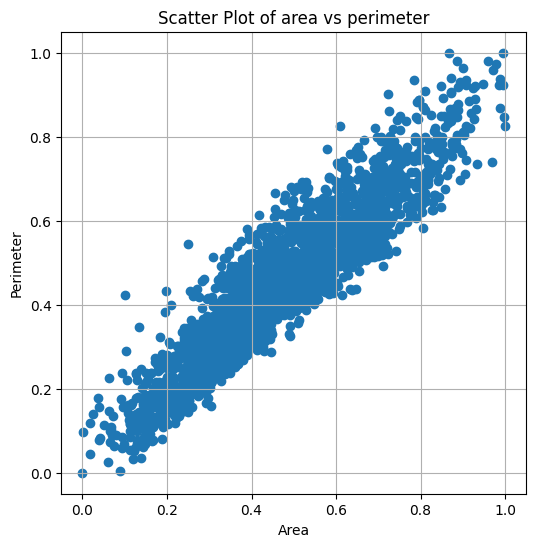

In [12]:
# Bivariate analysis: Scatter Plot of Area vs Perimeter
plt.figure(figsize=(6, 6))
plt.scatter(data['Area'], data['Perimeter'])
plt.title('Scatter Plot of area vs perimeter')
plt.xlabel("Area")
plt.ylabel("Perimeter")
plt.grid(True)
plt.show()

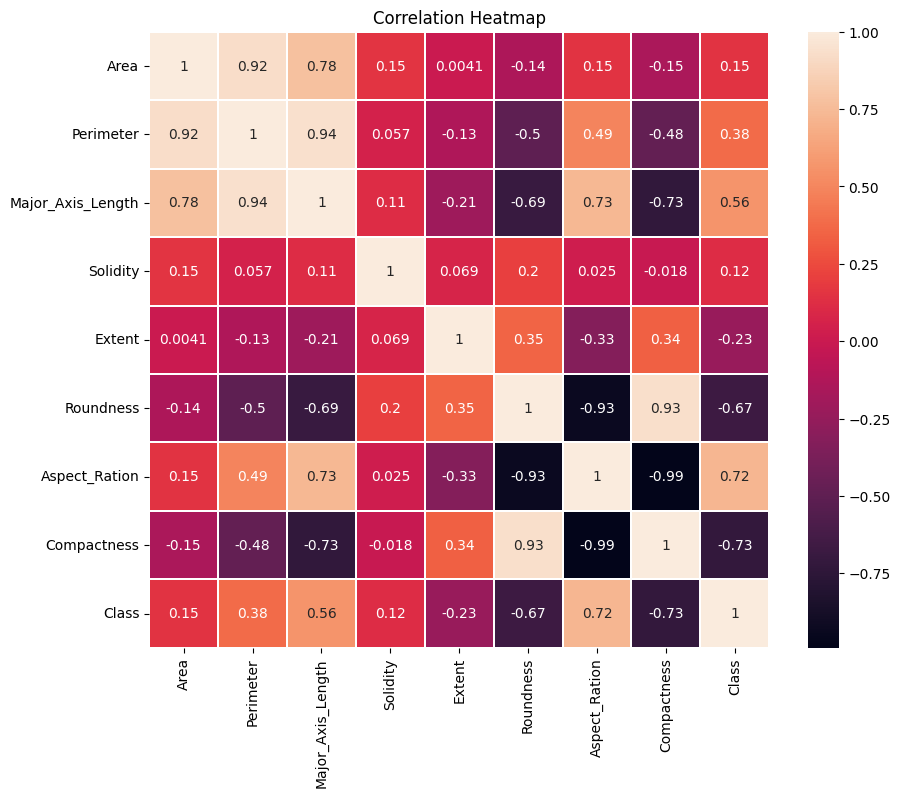

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
data['Class'] = encoder.fit_transform(data['Class'])

plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, linewidths=0.2)
plt.title("Correlation Heatmap")
plt.show()

In [15]:
# Splitting the data into X and Y
X = data.drop('Class', axis=1)
Y = data['Class']

# splitting into training and testing dataset
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=30)

# Print the shapes to verify the split
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(1985, 8)
(497, 8)
(1985,)
(497,)


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

logistic_regression = LogisticRegression()
logistic_regression.fit(x_train, y_train)
y_pred = logistic_regression.predict(x_test)

acc_lr = accuracy_score(y_test, y_pred)
c_lr = classification_report(y_test, y_pred)

print('Accuracy Score: ', acc_lr)
print(c_lr)

Accuracy Score:  0.8611670020120724
              precision    recall  f1-score   support

           0       0.84      0.91      0.87       257
           1       0.89      0.81      0.85       240

    accuracy                           0.86       497
   macro avg       0.86      0.86      0.86       497
weighted avg       0.86      0.86      0.86       497



In [17]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier()
random_forest.fit(x_train, y_train)
y_pred = random_forest.predict(x_test)

acc_rf = accuracy_score(y_test, y_pred)
c_rf = classification_report(y_test, y_pred)

print('Accuracy Score: ', acc_rf)
print(c_rf)

Accuracy Score:  0.8832997987927566
              precision    recall  f1-score   support

           0       0.86      0.92      0.89       257
           1       0.91      0.85      0.88       240

    accuracy                           0.88       497
   macro avg       0.89      0.88      0.88       497
weighted avg       0.88      0.88      0.88       497



In [18]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier()
decision_tree_model.fit(x_train, y_train)
y_pred = decision_tree_model.predict(x_test)

acc_dt = accuracy_score(y_test, y_pred)
c_dt = classification_report(y_test, y_pred)

print('Accuracy Score: ', acc_dt)
print(c_dt)

Accuracy Score:  0.8430583501006036
              precision    recall  f1-score   support

           0       0.84      0.87      0.85       257
           1       0.85      0.82      0.83       240

    accuracy                           0.84       497
   macro avg       0.84      0.84      0.84       497
weighted avg       0.84      0.84      0.84       497



In [19]:
from sklearn.naive_bayes import MultinomialNB

NB = MultinomialNB()
NB.fit(x_train, y_train)
y_pred = NB.predict(x_test)

acc_nb = accuracy_score(y_test, y_pred)
c_nb = classification_report(y_test, y_pred)

print('Accuracy Score: ', acc_nb)
print(c_nb)

Accuracy Score:  0.7022132796780685
              precision    recall  f1-score   support

           0       0.64      0.96      0.77       257
           1       0.92      0.42      0.58       240

    accuracy                           0.70       497
   macro avg       0.78      0.69      0.67       497
weighted avg       0.77      0.70      0.68       497



In [20]:
from sklearn.svm import SVC

support_vector = SVC()
support_vector.fit(x_train, y_train)
y_pred = support_vector.predict(x_test)

acc_svc = accuracy_score(y_test, y_pred)
c_svc = classification_report(y_test, y_pred)

print('Accuracy Score: ', acc_svc)
print(c_svc)

Accuracy Score:  0.8651911468812877
              precision    recall  f1-score   support

           0       0.83      0.92      0.88       257
           1       0.91      0.80      0.85       240

    accuracy                           0.87       497
   macro avg       0.87      0.86      0.86       497
weighted avg       0.87      0.87      0.86       497



In [21]:
from sklearn.ensemble import GradientBoostingClassifier

GBC = GradientBoostingClassifier()
GBC.fit(x_train, y_train)
y_pred = GBC.predict(x_test)

acc_gbc = accuracy_score(y_test, y_pred)
c_gbc = classification_report(y_test, y_pred)

print('Accuracy Score: ', acc_gbc)
print(c_gbc)

Accuracy Score:  0.8893360160965795
              precision    recall  f1-score   support

           0       0.87      0.93      0.90       257
           1       0.91      0.85      0.88       240

    accuracy                           0.89       497
   macro avg       0.89      0.89      0.89       497
weighted avg       0.89      0.89      0.89       497



In [22]:
# Testing the model with a custom data point
# These 8 numbers represent the 8 features we kept: Area, Perimeter, Major_Axis_Length, Solidity, Extent, Roundness, Aspect_Ration, Compactness
prediction = random_forest.predict([[0.410519, 0.340661, 0.294143, 0.9916, 0.7151, 0.8440, 1.7811, 0.7487]])

print(prediction[0])

# Mapping the numeric prediction back to the actual seed name
if prediction[0] == 0:
    print("Your seed lies in Çerçevelik class")
elif prediction[0] == 1:
    print("Your seed lies in Ürgüp Sivrisi class")

0
Your seed lies in Çerçevelik class


In [ ]:
# Create a DataFrame to compare the accuracy scores of all models
model = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree Classifier', 'RandomForest Classifier', 
              'Multinomial Naive Bayes', 'Support Vector Classifier', 'Gradient Boost Classifier'],
    'Score': [acc_lr, acc_dt, acc_rf, acc_nb, acc_svc, acc_gbc]
})

# Display the comparison table
model

,Model,Score
0,Logistic Regression,0.861167
1,Decision Tree Classifier,0.843058
2,RandomForest Classifier,0.883300
3,Multinomial Naive Bayes,0.702213
4,Support Vector Classifier,0.865191
5,Gradient Boost Classifier,0.889336


In [ ]:
import pickle
import warnings

pickle.dump(random_forest, open("model.pkl", "wb"))